In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
pd.set_option('display.max_columns', 40)

import matplotlib.pyplot as plt

In [3]:
# Scikit-learn/time
import sklearn
sklearn.set_config(transform_output='pandas')

from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score
from sktime.performance_metrics.forecasting import (
    MeanAbsoluteScaledError, 
    MeanAbsolutePercentageError, 
    MeanSquaredError, 
    MeanAbsoluteError
)

In [4]:
# ML model libraries
import xgboost as xgb

# ML aux. methods
import dataset as ds
import helper as hl

# Define Global Variables

In [5]:
DATA_PATH = os.path.join('..', 'data')
DATA_NAME, SR_FREQ, MIN_POINTS = 'paloalto', '12H', 100    # dundee | porto | boulder | paloalto

ROLLING_WINDOW_SIZE, MIN_PERIODS = 6, 4

# Load Dundee Dataset

In [6]:
df_evse_demand_v3 = pd.read_pickle(
    os.path.join(
        DATA_PATH, 'pkl', 
        f"{DATA_NAME}_data.demand_{SR_FREQ}_{MIN_POINTS}_points.enriched.v4.pickle"
    )
).sort_index()

# Feature Engineering

### Set forecasting target

In [7]:
# Set forecasting target
df_evse_demand_v3.loc[:, 'power_next'] = df_evse_demand_v3.groupby(level=1)['power_curr'].shift(-1)

### Rolling Statistics

In [8]:
# Simple Average/StD of Consumption
df_evse_demand_v3.loc[:, 'power_curr_sma'] = df_evse_demand_v3.groupby(level=1)['power_curr'].rolling(ROLLING_WINDOW_SIZE, min_periods=MIN_PERIODS, center=False).mean().reset_index(level=0, drop=True)   # SMA5
df_evse_demand_v3.loc[:, 'power_curr_std'] = df_evse_demand_v3.groupby(level=1)['power_curr'].rolling(ROLLING_WINDOW_SIZE, min_periods=MIN_PERIODS, center=False).std().reset_index(level=0, drop=True)    # VMA5; a = 2 / (span + 1)

# Exponential Average of Consumption
df_evse_demand_v3.loc[:, 'power_curr_ema'] = df_evse_demand_v3.groupby(level=1)['power_curr'].ewm(span=ROLLING_WINDOW_SIZE, min_periods=MIN_PERIODS, adjust=True).mean().reset_index(level=0, drop=True)    # EMA5; a = 2 / (span + 1)

# Calculate percentage of zero demand (Skaloumpakas et al. 2024)
df_evse_demand_v3.loc[:, f'zero_demand_pct_{SR_FREQ}'] = df_evse_demand_v3.groupby(level=1)[f'is_offline'].rolling(ROLLING_WINDOW_SIZE, min_periods=MIN_PERIODS, center=False).mean().reset_index(level=0, drop=True)

# Rolling min/max Ratio
df_evse_demand_v3.loc[:, "power_curr_range"] = \
    df_evse_demand_v3.groupby(level=1)['power_curr'].rolling(ROLLING_WINDOW_SIZE, min_periods=MIN_PERIODS, center=False).max().reset_index(level=0, drop=True) - \
    df_evse_demand_v3.groupby(level=1)['power_curr'].rolling(ROLLING_WINDOW_SIZE, min_periods=MIN_PERIODS, center=False).min().reset_index(level=0, drop=True)

### Scale variables by constant value(s)

In [9]:
# Scale charging time by max amount of duration (c.f., preprocessing)
df_evse_demand_v3['charging_time'] = df_evse_demand_v3['charging_time'] / 2880  # 2280 --> 48hrs in minutes

In [10]:
# Normalize energy demand by maximum energy output of each EVCS, so that the energy will be around the range [0, 1]. 
# Some stations will report values higher than their output, however that is expected, 
# since we know - from domain experts - that EVCSs may exceed their nominal value by a factor of ±10%
evse_max_energy_kwh = (df_evse_demand_v3['power_output_kW'] * (pd.Timedelta(SR_FREQ.lower()).total_seconds() / 3600)).values

for col_name in df_evse_demand_v3.columns:
    if 'power_curr' not in col_name:
        continue

    df_evse_demand_v3.loc[:, f'{col_name}'] = df_evse_demand_v3.loc[:, f'{col_name}'] / evse_max_energy_kwh

# Normalize extrapolated energy demand
df_evse_demand_v3.loc[:, 'power_next_step1_extrap'] = df_evse_demand_v3.loc[:, 'power_next_step1_extrap'] / evse_max_energy_kwh

### Lagged feature(s)

In [11]:
df_evse_demand_v3 = df_evse_demand_v3.groupby(
    level=1, group_keys=False, as_index=False
).apply(
    lambda l: l.assign(**{
        **{
            f'{"power_curr"}_lag{lag}': df_evse_demand_v3["power_curr"].shift(lag) for lag in [5, 24, 48]
        }, **{
            f'{"power_curr_ema"}_lag{lag}': df_evse_demand_v3["power_curr_ema"].shift(lag) for lag in [5, 24, 48]
        }, **{
            f'{"power_curr_std"}_lag{lag}': df_evse_demand_v3["power_curr_std"].shift(lag) for lag in [5, 24, 48]
        }, **{
            f'{"no_of_sessions"}_lag{lag}': df_evse_demand_v3["no_of_sessions"].shift(lag) for lag in [5, 24, 48]
        }, **{
            f'{"charging_time"}_lag{lag}': df_evse_demand_v3["charging_time"].shift(lag) for lag in [5, 24, 48]
        }, **{
            f'zero_demand_pct_{SR_FREQ}_lag{lag}': df_evse_demand_v3[f'zero_demand_pct_{SR_FREQ}'].shift(lag) for lag in [5, 24, 48]
        }
    })
)

df_evse_demand_v3.dropna(inplace=True)

# Split Dataset to Train/Dev/Test sets

In [12]:
X, y_clf, y_reg = (
    df_evse_demand_v3.drop('power_next', axis=1).copy(), 
    df_evse_demand_v3.loc[:, 'power_next'].copy() == 0,
    df_evse_demand_v3.loc[:, 'power_next'].copy()
)

X.reset_index(level=(1,2), inplace=True)
X.oid = X.oid.astype('category')
X.Site = X.Site.astype('category')
X.power_output_kW = X.power_output_kW.astype('category')
X.is_offline = X.power_output_kW.astype('bool')

y_clf.reset_index(level=(1,2), drop=True, inplace=True)
y_reg.reset_index(level=(1,2), drop=True, inplace=True)

In [13]:
dundee_dates = pd.Series(df_evse_demand_v3.index.get_level_values(2)).dt.date.sort_values().unique()
dundee_dates_train_ix, dundee_dates_dev_ix, dundee_dates_test_ix = ds.timeseries_train_test_split(dundee_dates, dev_size=0.2, test_size=0.1, stratify=None, shuffle=False)

print(f'Train \t@{(min(dundee_dates[dundee_dates_train_ix]), max(dundee_dates[dundee_dates_train_ix]))=};'+\
f'\nDev \t@{(min(dundee_dates[dundee_dates_dev_ix]), max(dundee_dates[dundee_dates_dev_ix]))=};'+\
f'\nTest \t@{(min(dundee_dates[dundee_dates_test_ix]), max(dundee_dates[dundee_dates_test_ix]))=}')

Train 	@(min(dundee_dates[dundee_dates_train_ix]), max(dundee_dates[dundee_dates_train_ix]))=(datetime.date(2011, 7, 31), datetime.date(2018, 3, 5));
Dev 	@(min(dundee_dates[dundee_dates_dev_ix]), max(dundee_dates[dundee_dates_dev_ix]))=(datetime.date(2018, 3, 6), datetime.date(2020, 1, 22));
Test 	@(min(dundee_dates[dundee_dates_test_ix]), max(dundee_dates[dundee_dates_test_ix]))=(datetime.date(2020, 1, 23), datetime.date(2021, 1, 1))


# Predict the entire time-series

In [14]:
XGB_FEATS_IMPROVED = [
    'power_output_kW',
    'no_of_sessions',
    'charging_time',
    'week_sin', 'week_cos', 
    'day_sin', 'day_cos',
    'hour_sin', 'hour_cos',
    # 
    'power_curr_lag1',
    'power_curr', 
    'power_curr_logdelta',
    'power_next_step1_extrap', 
    #  
    'power_curr_std', 
    'power_curr_ema', 
    # 
    'power_curr_lag5', 'power_curr_lag48',
    'power_curr_ema_lag24', 'power_curr_ema_lag48',
    'power_curr_std_lag24', 'power_curr_std_lag48',
    #
    f'downtime_scaled'
]

In [15]:
train_ix, dev_ix, test_ix = X.loc[X['timestamp'].dt.date.isin(dundee_dates[dundee_dates_train_ix])].index,\
                            X.loc[X['timestamp'].dt.date.isin(dundee_dates[dundee_dates_dev_ix])].index,\
                            X.loc[X['timestamp'].dt.date.isin(dundee_dates[dundee_dates_test_ix])].index

(
    X_train, y_train,
    X_dev, y_dev,
    X_test, y_test
) = (
    X.loc[train_ix, :].copy(), y_reg.loc[train_ix].copy(), 
    X.loc[dev_ix, :].copy(), y_reg.loc[dev_ix].copy(), 
    X.loc[test_ix, :].copy(), y_reg.loc[test_ix].copy(), 
)

### Scale variables by AbsMax values per EVSE (needs training/dev/test splits)

In [16]:
downtime_norm_const = X_train[f'downtime'].max()
uptime_norm_const = X_train[f'uptime'].max()
no_of_sessions_norm_const = X_train[f'no_of_sessions'].max()

X_train.loc[:, f'downtime_scaled'] = X_train[f'downtime'] / downtime_norm_const
X_dev.loc[:, f'downtime_scaled'] = X_dev[f'downtime'] / downtime_norm_const
X_test.loc[:, f'downtime_scaled'] = X_test[f'downtime'] / downtime_norm_const

X_train.loc[:, f'uptime_scaled'] = X_train[f'uptime'] / uptime_norm_const
X_dev.loc[:, f'uptime_scaled'] = X_dev[f'uptime'] / uptime_norm_const
X_test.loc[:, f'uptime_scaled'] = X_test[f'uptime'] / uptime_norm_const

X_train.loc[:, f'no_of_sessions_scaled'] = X_train[f'no_of_sessions'] / no_of_sessions_norm_const
X_dev.loc[:, f'no_of_sessions_scaled'] = X_dev[f'no_of_sessions'] / no_of_sessions_norm_const
X_test.loc[:, f'no_of_sessions_scaled'] = X_test[f'no_of_sessions'] / no_of_sessions_norm_const

In [17]:
xgb_online = xgb.XGBRegressor(
    objective="reg:quantileerror", quantile_alpha=0.7, 
    n_estimators=50,
    max_depth=5, 
    n_jobs=-1, 
    random_state=3407, 
    base_score=0,
    learning_rate=1e-1, 
    # early_stopping_rounds=10, 
    enable_categorical=True,
)

model = TransformedTargetRegressor(
    regressor=xgb_online,
)

model.fit(
    X_train[XGB_FEATS_IMPROVED], y_train, 
    eval_set=[
        (X_train[XGB_FEATS_IMPROVED], y_train),
        (X_dev[XGB_FEATS_IMPROVED], y_dev),
    ], 
    verbose=True
)

model.score(X_test[XGB_FEATS_IMPROVED], y_test)

[0]	validation_0-quantile:12.74828	validation_1-quantile:10.56780
[1]	validation_0-quantile:11.31767	validation_1-quantile:9.44581
[2]	validation_0-quantile:10.07776	validation_1-quantile:8.51364
[3]	validation_0-quantile:9.00996	validation_1-quantile:7.73057
[4]	validation_0-quantile:8.08551	validation_1-quantile:7.09131
[5]	validation_0-quantile:7.30620	validation_1-quantile:6.56830
[6]	validation_0-quantile:6.63665	validation_1-quantile:6.12927
[7]	validation_0-quantile:6.08159	validation_1-quantile:5.76267
[8]	validation_0-quantile:5.60502	validation_1-quantile:5.43938
[9]	validation_0-quantile:5.21028	validation_1-quantile:5.18922
[10]	validation_0-quantile:4.88075	validation_1-quantile:4.97419
[11]	validation_0-quantile:4.60834	validation_1-quantile:4.80587
[12]	validation_0-quantile:4.38675	validation_1-quantile:4.66919
[13]	validation_0-quantile:4.20307	validation_1-quantile:4.55750
[14]	validation_0-quantile:4.05088	validation_1-quantile:4.45704
[15]	validation_0-quantile:3.92

0.37631689285944414

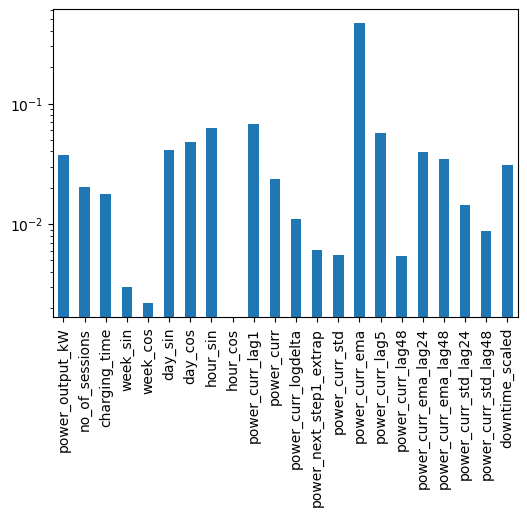

In [18]:
fig, ax = plt.subplots(1,1, figsize=(6, 4))

pd.Series(model.regressor_.feature_importances_, index=model.regressor_.feature_names_in_).plot.bar(ax=ax)
ax.set_yscale('log')

plt.savefig(f'{DATA_PATH}/fig/xgboost_feature_importance.online.v4.{DATA_NAME}.improved.png', dpi=400, bbox_inches='tight')
plt.show()

# Evaluate predictions

In [19]:
mask = (
    df_evse_demand_v3.reset_index().timestamp.dt.date.isin(dundee_dates[dundee_dates_test_ix]).values
)
series_test = df_evse_demand_v3.loc[mask].copy()

series_test.Site = series_test.Site.astype('category')
series_test.power_output_kW = series_test.power_output_kW.astype('category')

series_test.loc[:, 'downtime_scaled'] = series_test['downtime'] / downtime_norm_const
series_test.loc[:, 'uptime_scaled'] = series_test['uptime'] / uptime_norm_const

series_test.loc[:, 'XGBoost'] = model.predict(
    series_test.reset_index()[XGB_FEATS_IMPROVED]
).clip(min=0)

In [20]:
series_test_preds = series_test[['power_next', 'XGBoost']].reset_index(level=0, drop=True).copy()

In [21]:
available_oids = list(
    set(
        X_test.oid.unique()
    ).intersection(
        set(X_train.oid.unique())
    )
)

model_results_metrics = hl.evaluate_predictions(
    # Compare with EVSEs that exist in the train set (necessary for MASE to work)
    series_test_preds.loc[
        pd.IndexSlice[available_oids, :], :
    ],
    y_true_name='power_next',
    y_pred_names=['XGBoost'],
    eval_funs=[
        ('MASE_pct', MeanAbsoluteScaledError(sp=24), {'y_train':y_train, 'oid_indices':X_train.groupby('oid', observed=False).groups}),
        ('SMAPE_pct', MeanAbsolutePercentageError(symmetric=True), {}),
        ('MAAPE_rads', hl.mean_arctangent_absolute_percentage_error, {}),
        ('WAPE_pct', hl.wape, {}),
        ('RMSE_kW', MeanSquaredError(square_root=True), {}),
        ('MAE_kW', MeanAbsoluteError(), {}),
        ('R2', r2_score, {}),
    ]
)

In [22]:
model_results_metrics.groupby(level=0, sort=False).describe().T.loc[
    pd.IndexSlice[:, ['mean', '25%', '50%', '75%']], :
].round(2)

0_MASE_pct  1_SMAPE_pct  2_MAAPE_rads  3_WAPE_pct  4_RMSE_kW  \
XGBoost mean        0.58         1.06          0.86        1.60       9.58   
        25%         0.40         0.96          0.78        0.86       8.29   
        50%         0.58         1.14          0.93        0.90       9.92   
        75%         0.69         1.25          1.00        1.08      11.82   

              5_MAE_kW  6_R2  
XGBoost mean      7.05 -0.21  
        25%       5.90  0.03  
        50%       7.49  0.29  
        75%       9.18  0.41

In [23]:
series_test_preds.to_pickle(f'{DATA_PATH}/pkl/{DATA_NAME}_data.demand_{SR_FREQ}.EVSE_{"_XGBoost_BOTH_DEMAND_PERIODS_"}_model.v4.pickle')
model_results_metrics.to_pickle(f'{DATA_PATH}/pkl/{DATA_NAME}_data.demand_{SR_FREQ}.EVSE_{"_XGBoost_BOTH_DEMAND_PERIODS_"}_model.metrics.v4.pickle')